In [109]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
sns.set(style="darkgrid")
np.random.seed(42)
N = 256
tiempo = np.arange(N)

# Señal seno con 2 ciclos
ciclos = 2
amplitud = 1
seno2 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Señal seno con 10 ciclos
ciclos = 10
amplitud = 1
seno10 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Señal seno con 20 ciclos
ciclos = 20
amplitud = 2
seno20 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Nivel DC
nivel_dc = np.ones(N)

# Nivel de ruido gaussiano con media 0 y desviación estándar 0.5
ruido = np.random.normal(loc=0, scale=0.5, size=N)

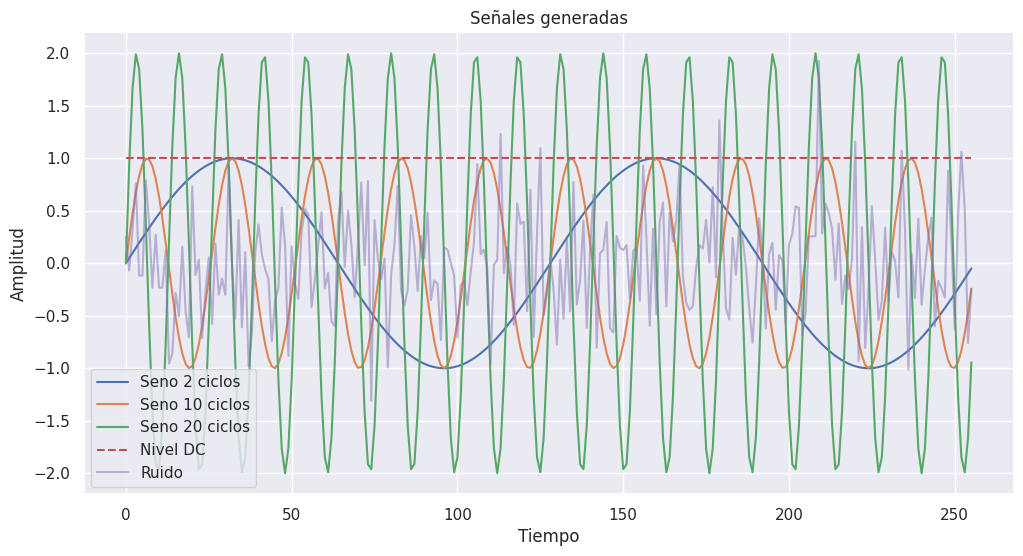

In [111]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=tiempo, y=seno2, label='Seno 2 ciclos')
sns.lineplot(x=tiempo, y=seno10, label='Seno 10 ciclos')
sns.lineplot(x=tiempo, y=seno20, label='Seno 20 ciclos')
sns.lineplot(x=tiempo, y=nivel_dc, label='Nivel DC', linestyle='dashed')
sns.lineplot(x=tiempo, y=ruido, label='Ruido', alpha=0.5)
plt.title('Señales generadas')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

In [112]:
# Serie combinada
serie = seno2 + seno10 + seno20 + nivel_dc + ruido
serie_fft = np.fft.fft(serie)

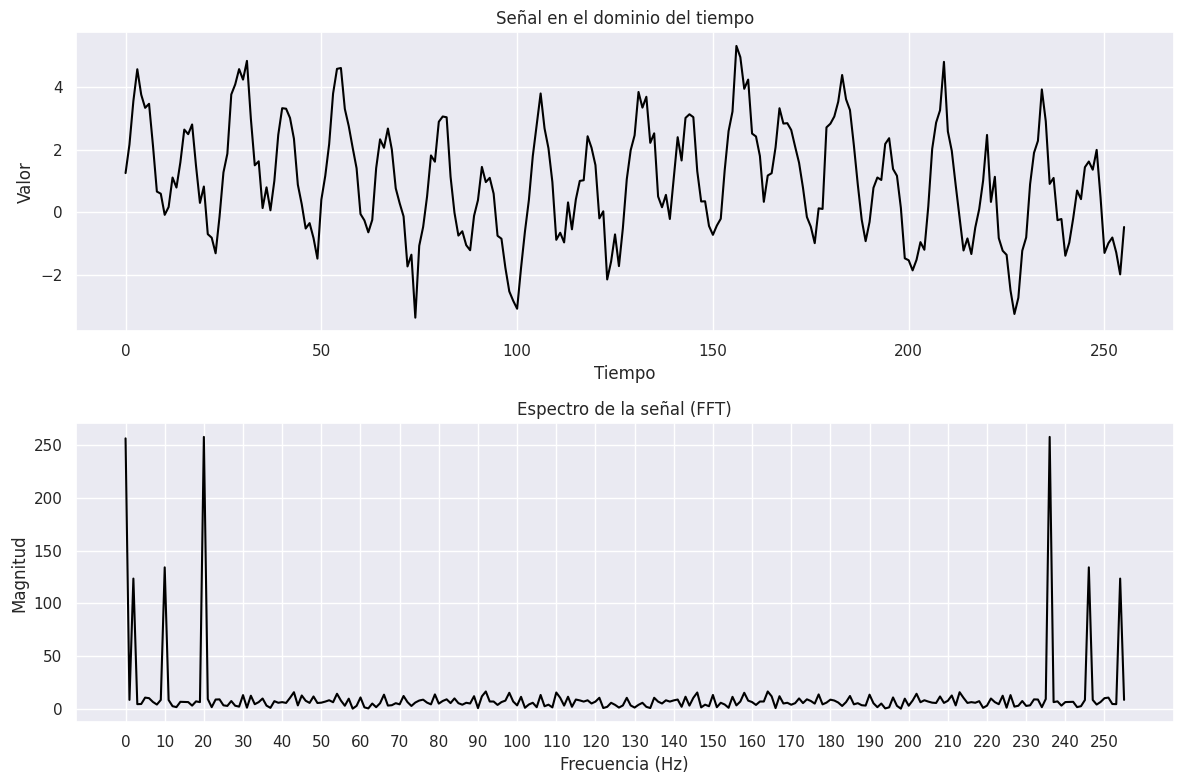

In [113]:
_, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(x=tiempo, y=serie, ax=axes[0], color='black')
axes[0].set_title("Señal en el dominio del tiempo")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Valor")

# Eje Y es magnitud, calculada con abs()
sns.lineplot(x=tiempo, y=np.abs(serie_fft), ax=axes[1], color='black')
axes[1].set_title("Espectro de la señal (FFT)")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("Magnitud")
axes[1].set_xticks(range(0, N, 10))

plt.tight_layout()
plt.show()

- Pico en el 0: nivel DC, constante
- Pico en el 2 y en el 10: indican presencia de componentes que forman 2 y 10 ciclos de magnitud similar respectivamente
- Pico en el 20: indica componente cíclico de 20, con el doble de magnitud que los de 2 y 10, sugiriendo una amplitud del doble
- Ruido

# Aplicación de filtros

## Pasa-Altos

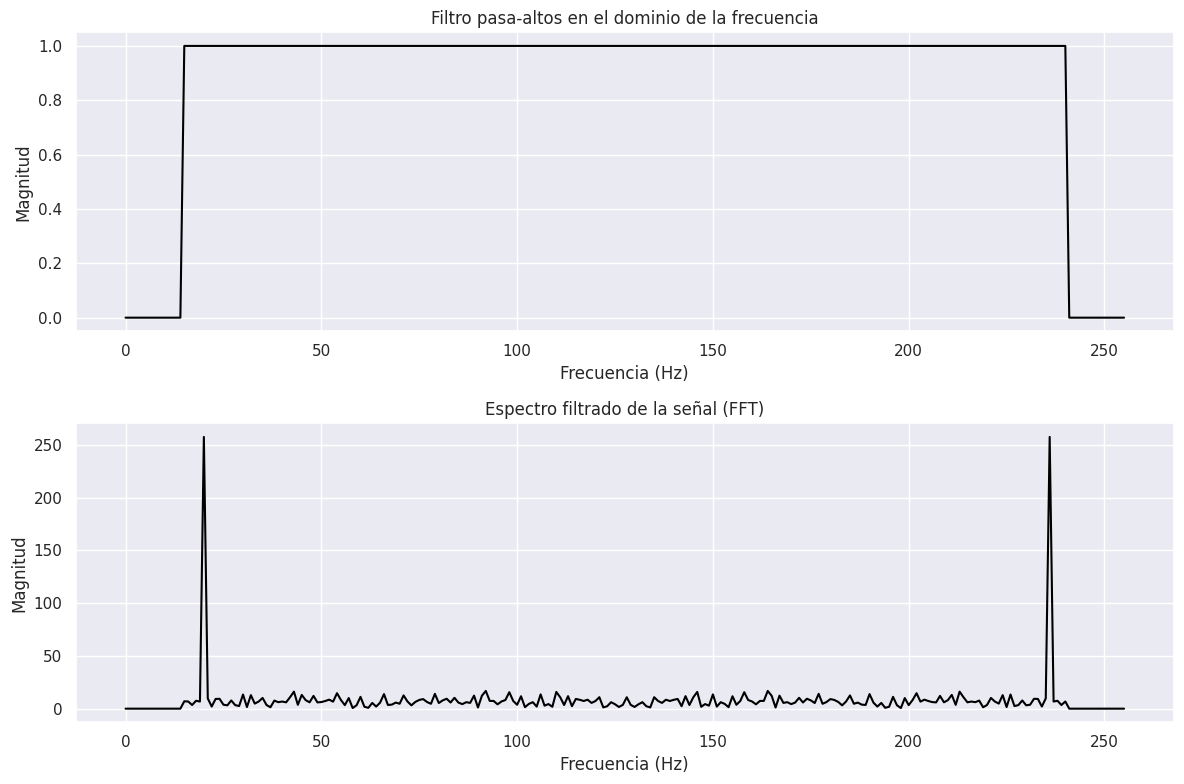

In [114]:
# Filtrado en el dominio de la frecuencia (pasa altos, elimina bajos)
filtro_dom_freq = np.zeros(N)
rango_pasa_altos = 15
filtro_dom_freq[rango_pasa_altos:-rango_pasa_altos] = 1

# Aplicar filtro en la frecuencia
serie_fft_filtrada = filtro_dom_freq * serie_fft

_, axes = plt.subplots(2, 1, figsize=(12, 8))

# Ploteo el filtro
sns.lineplot(x=tiempo, y=filtro_dom_freq, ax=axes[0], color='black')
axes[0].set_title("Filtro pasa-altos en el dominio de la frecuencia")
axes[0].set_xlabel("Frecuencia (Hz)")
axes[0].set_ylabel("Magnitud")

# Nuevament, para magnitud, uso abs()
sns.lineplot(x=tiempo, y=np.abs(serie_fft_filtrada), ax=axes[1], color='black')
axes[1].set_title("Espectro filtrado de la señal (FFT)")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("Magnitud")

plt.tight_layout()
plt.show()

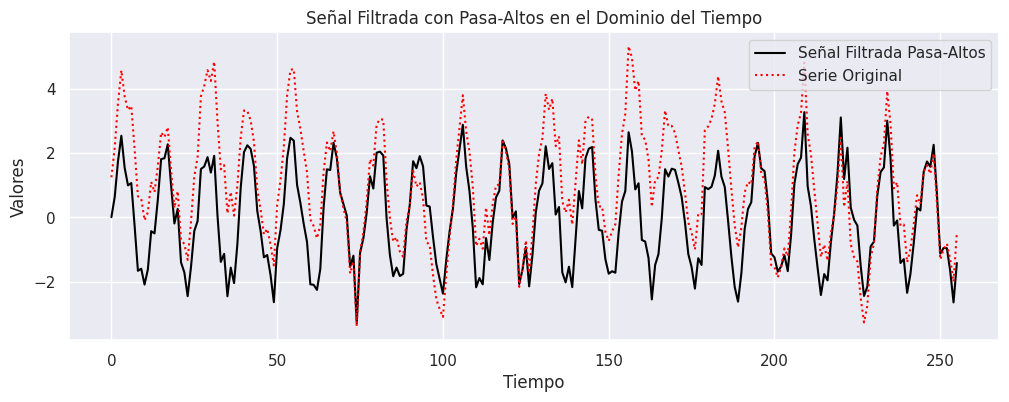

In [115]:
# Transformada inversa para recuperar la señal filtrada
serie_filtrada = np.fft.ifft(serie_fft_filtrada).real

# Graficar
plt.figure(figsize=(12, 4))
sns.lineplot(x=tiempo, y=serie_filtrada, label="Señal Filtrada Pasa-Altos", color='black')
sns.lineplot(x=tiempo, y=serie, label="Serie Original", color='red', linestyle='dotted')
plt.title("Señal Filtrada con Pasa-Altos en el Dominio del Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend()
plt.show()

Le eliminó las componentes de baja frecuencia (principalmente los picos de 2 y 10 que vimos antes)

---

## Pasa-Bajos

Buscamos ahora eliminar el ruido

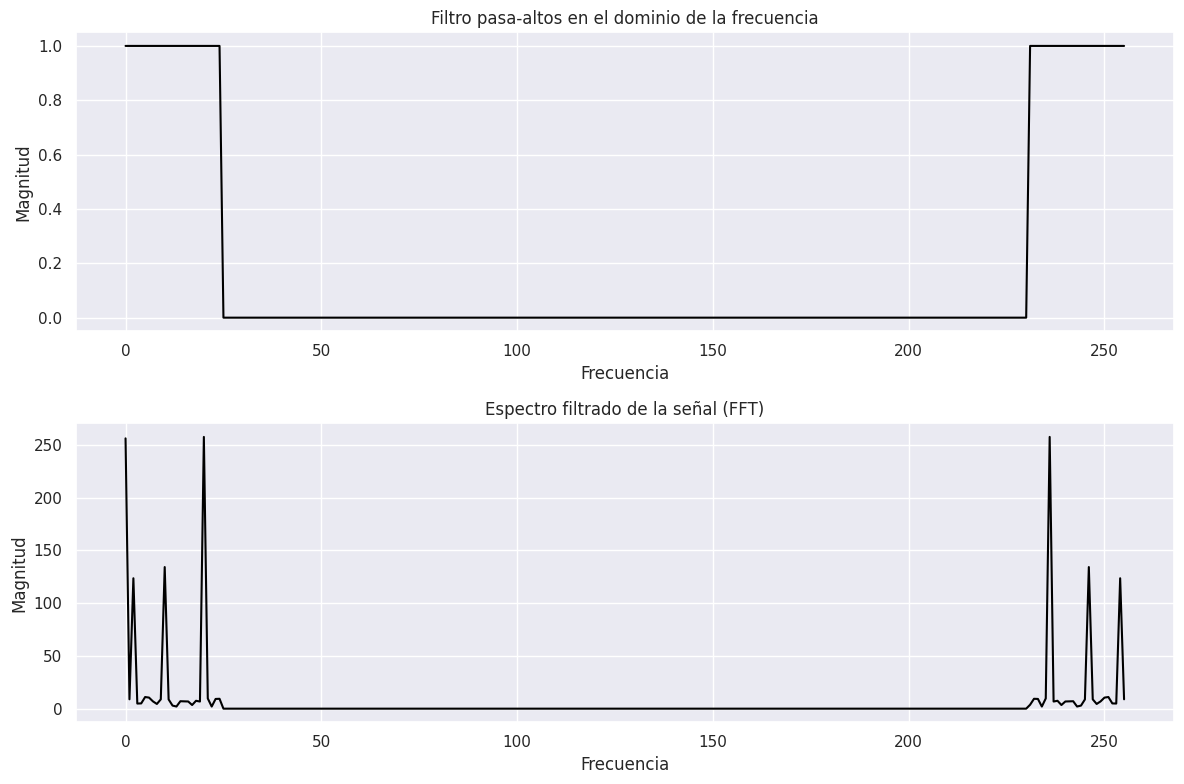

In [116]:
# Filtrado en el dominio de la frecuencia (pasa bajos)
filtro_dom_freq = np.ones(N)
rango_filtrado = 25
filtro_dom_freq[rango_filtrado:-rango_filtrado] = 0

# Aplicar filtro en la frecuencia
serie_fft_filtrada = filtro_dom_freq * serie_fft

_, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(x=tiempo, y=filtro_dom_freq, ax=axes[0], color='black')
axes[0].set_title("Filtro pasa-altos en el dominio de la frecuencia")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Magnitud")
sns.lineplot(x=tiempo, y=np.abs(serie_fft_filtrada), ax=axes[1], color='black')
axes[1].set_title("Espectro filtrado de la señal (FFT)")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Magnitud")

plt.tight_layout()
plt.show()

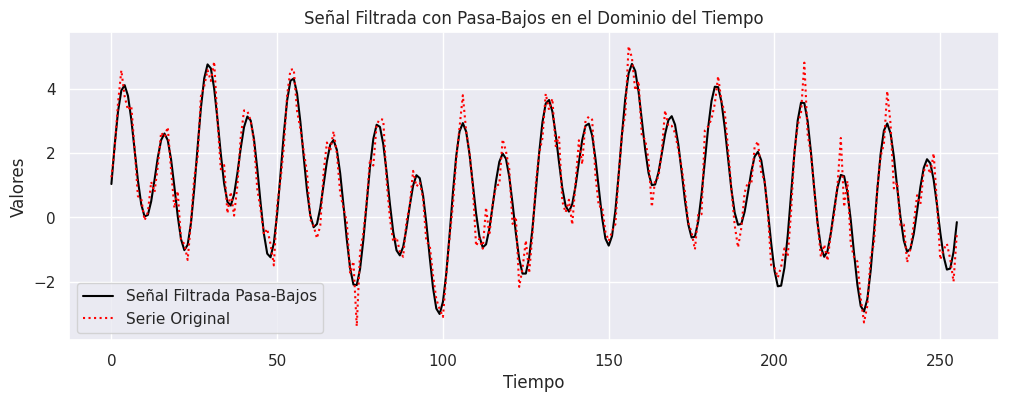

In [117]:
# Transformada inversa para recuperar la señal filtrada
serie_filtrada = np.fft.ifft(serie_fft_filtrada).real

# Graficar
plt.figure(figsize=(12, 4))
sns.lineplot(x=tiempo, y=serie_filtrada, label="Señal Filtrada Pasa-Bajos", color='black')
sns.lineplot(x=tiempo, y=serie, label="Serie Original", color='red', linestyle='dotted')
plt.title("Señal Filtrada con Pasa-Bajos en el Dominio del Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend()
plt.show()